# 03 — Model Comparison & Training

**Goal:** Compare regression models, select the best one for risk score prediction.

| Model | Type | How it works |
|-------|------|-------------|
| Linear Regression | Baseline | Fits a straight line through the data |
| Random Forest | Ensemble (bagging) | Many independent trees, average their predictions |
| Gradient Boosting | Ensemble (boosting) | Trees built sequentially, each fixing previous errors |
| XGBoost | Optimized boosting | Faster, regularized version of gradient boosting |

**Evaluation:** MAE, RMSE, R² via 5-fold cross-validation

In [2]:
import sys
import os
import mlflow
import mlflow.sklearn
import joblib

os.chdir(os.path.dirname(os.getcwd()))


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from geopy.distance import geodesic

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

%matplotlib inline

---
## 1. Load Data & Compute Hotspot Distances
Merge driver data with cluster distances to create the full feature set.

In [4]:
driver_df = pd.read_csv('data/processed/drivers_raw.csv')
hh_df = pd.read_csv('data/processed/household_coords.csv')
cluster_summary = pd.read_csv('data/processed/cluster_summary.csv')

print(f"Drivers:    {driver_df.shape}")
print(f"Households: {hh_df.shape}")
print(f"Clusters:   {cluster_summary.shape}")
print(f"\nCluster summary:")
print(cluster_summary.to_string(index=False))

Drivers:    (100346, 18)
Households: (100169, 3)
Clusters:   (6, 4)

Cluster summary:
 cluster  longitude  latitude  cnt
       3 -87.614070 41.743172 2026
       4 -87.641917 41.874353 1664
       2 -87.727940 41.885578 1490
       0 -87.703842 41.785188 1290
       1 -87.682439 41.963758 1211
       5 -87.781328 41.953157  780


In [5]:
import time
t0 = time.time()

hh_coords = hh_df[['LATITUDE', 'LONGITUDE']].values
cluster_coords = cluster_summary[['latitude', 'longitude']].values

n_clusters = len(cluster_summary)
hotspot_cols = [f'HOTSPOT{i+1}' for i in range(n_clusters)]

for i, col in enumerate(hotspot_cols):
    distances = [
        math.floor(0.5 + geodesic(hh, cluster_coords[i]).miles)
        for hh in hh_coords
    ]
    hh_df[col] = distances

t1 = time.time()
print(f"Computed {n_clusters} hotspot distances for {len(hh_df):,} households in {(t1-t0)/60:.1f} minutes")
hh_df.head()

Computed 6 hotspot distances for 100,169 households in 0.5 minutes


,HOUSEHOLD_ID,LATITUDE,LONGITUDE,HOTSPOT1,HOTSPOT2,HOTSPOT3,HOTSPOT4,HOTSPOT5,HOTSPOT6
0,EF07926,42.106590,-87.776629,26,17,15,22,11,11
1,MJ58257,41.950807,-87.658336,15,5,6,12,2,6
2,DJ17771,41.901205,-87.672055,11,2,3,8,4,7
3,ML06244,42.137056,-87.851188,30,21,18,25,15,13
4,CK03697,41.770331,-87.731943,6,9,8,2,14,13


In [6]:
merged_df = driver_df.merge(hh_df, on='HOUSEHOLD_ID', how='inner')
print(f"Merged: {merged_df.shape}")
print(f"Columns: {list(merged_df.columns)}")
merged_df.head()

Merged: (100346, 26)
Columns: ['HOUSEHOLD_ID', 'POLICY_ID', 'ZIPCODE', 'NB_DRIVERS', 'UNDER25', 'OVER60', 'MALE25', 'PRIM_DRIVER_AGE', 'PRIM_DRIVER_GENDER', 'MAKE_MODEL', 'MODEL_YEAR', 'INITIAL_ODOMETER', 'LOW_MILEAGE_USE', 'NB_CLAIMS', 'CLAIM_TOTAL', 'NB_PRIM_CLAIMS', 'PRIM_CLAIM_TOTAL', 'RISK', 'LATITUDE', 'LONGITUDE', 'HOTSPOT1', 'HOTSPOT2', 'HOTSPOT3', 'HOTSPOT4', 'HOTSPOT5', 'HOTSPOT6']


,HOUSEHOLD_ID,POLICY_ID,ZIPCODE,NB_DRIVERS,UNDER25,OVER60,MALE25,PRIM_DRIVER_AGE,PRIM_DRIVER_GENDER,MAKE_MODEL,...,PRIM_CLAIM_TOTAL,RISK,LATITUDE,LONGITUDE,HOTSPOT1,HOTSPOT2,HOTSPOT3,HOTSPOT4,HOTSPOT5,HOTSPOT6
0,GG97480,VT0428041,60025,4.0,0,3,0,70,F,Honda CR-V,...,NaN,28,42.077678,-87.800198,25,16,14,21,10,9
1,DF10801,NP4091094,60513,1.0,0,1,0,71,F,Kia Sportage,...,NaN,32,41.826677,-87.851210,14,11,8,8,13,9
2,IH57853,NQ6757344,60193,1.0,0,1,0,72,F,Ford Fusion,...,NaN,23,42.000494,-88.076790,30,24,20,24,20,16
3,GA01525,NQ0913159,60646,2.0,0,1,0,75,M,Honda Accord,...,NaN,36,41.996975,-87.737571,19,10,8,15,4,4
4,GH49152,UU8662035,60639,5.0,0,1,0,32,M,Mercedes C Class,...,NaN,35,41.930943,-87.771502,15,8,4,11,5,2


---
## 2. Feature Engineering
Apply the same transformations as `engineering.py` — fill nulls, convert types, create VEHICLE_AGE.

In [7]:
df = merged_df.copy()

# Fill missing claims with 0
claim_cols = ['NB_CLAIMS', 'CLAIM_TOTAL', 'NB_PRIM_CLAIMS', 'PRIM_CLAIM_TOTAL']
for col in claim_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Convert LOW_MILEAGE_USE to int
df['LOW_MILEAGE_USE'] = pd.to_numeric(df['LOW_MILEAGE_USE'], errors='coerce').fillna(0).astype(int)

# Add VEHICLE_AGE
df['VEHICLE_AGE'] = 2025 - df['MODEL_YEAR']

# Ensure RISK is numeric
df['RISK'] = pd.to_numeric(df['RISK'], errors='coerce')
df = df.dropna(subset=['RISK'])

print(f"Prepared: {df.shape}")
print(f"\nRISK distribution:")
print(df['RISK'].describe())

Prepared: (100346, 27)

RISK distribution:
count    100346.000000
mean         28.117374
std           6.938707
min           3.000000
25%          23.000000
50%          29.000000
75%          33.000000
max          59.000000
Name: RISK, dtype: float64


In [8]:
hotspot_features = [f'HOTSPOT{i+1}' for i in range(n_clusters)]

numeric_features = [
    'NB_DRIVERS', 'UNDER25', 'OVER60', 'MALE25',
    'PRIM_DRIVER_AGE', 'MODEL_YEAR', 'INITIAL_ODOMETER',
    'NB_CLAIMS', 'CLAIM_TOTAL', 'NB_PRIM_CLAIMS', 'PRIM_CLAIM_TOTAL',
    'VEHICLE_AGE',
]

categorical_features = ['PRIM_DRIVER_GENDER']
binary_features = ['LOW_MILEAGE_USE']

drop_cols = ['ZIPCODE', 'MAKE_MODEL', 'HOUSEHOLD_ID', 'POLICY_ID',
             'LATITUDE', 'LONGITUDE', 'RISK']

# Drop identifier columns, keep features
feature_cols = hotspot_features + numeric_features + categorical_features + binary_features
X = df[feature_cols].copy()
y = df['RISK'].copy()

print(f"Features: {X.shape[1]}")
print(f"Samples:  {len(y):,}")
print(f"\nFeature list:")
for col in X.columns:
    print(f"  {col}: {X[col].dtype}")

Features: 20
Samples:  100,346

Feature list:
  HOTSPOT1: int64
  HOTSPOT2: int64
  HOTSPOT3: int64
  HOTSPOT4: int64
  HOTSPOT5: int64
  HOTSPOT6: int64
  NB_DRIVERS: float64
  UNDER25: int64
  OVER60: int64
  MALE25: int64
  PRIM_DRIVER_AGE: int64
  MODEL_YEAR: int64
  INITIAL_ODOMETER: float64
  NB_CLAIMS: float64
  CLAIM_TOTAL: float64
  NB_PRIM_CLAIMS: float64
  PRIM_CLAIM_TOTAL: float64
  VEHICLE_AGE: int64
  PRIM_DRIVER_GENDER: object
  LOW_MILEAGE_USE: int64


In [9]:
all_numeric = hotspot_features + numeric_features

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), all_numeric),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features),
        ('bin', 'passthrough', binary_features),
    ],
    remainder='drop',
)

print("Preprocessor built")
print(f"  Numeric columns ({len(all_numeric)}): scaled")
print(f"  Categorical columns ({len(categorical_features)}): one-hot encoded")
print(f"  Binary columns ({len(binary_features)}): passthrough")

Preprocessor built
  Numeric columns (18): scaled
  Categorical columns (1): one-hot encoded
  Binary columns (1): passthrough


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train):,} samples")
print(f"Test:  {len(X_test):,} samples")

Train: 80,276 samples
Test:  20,070 samples


---
## 3. Model Comparison
Train 4 models, compare with cross-validation.

In [11]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.15, random_state=42
    ),
}

results = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])
    
    # Cross-validation
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    cv_mae = cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    
    # Fit on full training set and evaluate on test
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    test_r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'pipeline': pipe,
        'cv_r2_mean': cv_r2.mean(),
        'cv_r2_std': cv_r2.std(),
        'cv_mae_mean': -cv_mae.mean(),
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2,
    }
    
    print(f"{name:25s} | CV R²: {cv_r2.mean():.4f} ± {cv_r2.std():.4f} | "
          f"Test MAE: {test_mae:.2f} | Test R²: {test_r2:.4f}")

Linear Regression         | CV R²: 0.8974 ± 0.0006 | Test MAE: 1.70 | Test R²: 0.8972
Random Forest             | CV R²: 0.8992 ± 0.0010 | Test MAE: 1.68 | Test R²: 0.8988
Gradient Boosting         | CV R²: 0.9148 ± 0.0005 | Test MAE: 1.46 | Test R²: 0.9144
XGBoost                   | CV R²: 0.9148 ± 0.0004 | Test MAE: 1.46 | Test R²: 0.9145


In [12]:
comp_df = pd.DataFrame([
    {
        'Model': name,
        'CV R² (mean)': round(data['cv_r2_mean'], 4),
        'CV R² (std)': round(data['cv_r2_std'], 4),
        'Test MAE': round(data['test_mae'], 2),
        'Test RMSE': round(data['test_rmse'], 2),
        'Test R²': round(data['test_r2'], 4),
    }
    for name, data in results.items()
]).sort_values('Test R²', ascending=False)

print("=== Model Comparison ===\n")
print(comp_df.to_string(index=False))

winner = comp_df.iloc[0]['Model']
print(f"\n✅ Winner: {winner}")

=== Model Comparison ===

            Model  CV R² (mean)  CV R² (std)  Test MAE  Test RMSE  Test R²
          XGBoost        0.9148       0.0004      1.46       2.03   0.9145
Gradient Boosting        0.9148       0.0005      1.46       2.03   0.9144
    Random Forest        0.8992       0.0010      1.68       2.21   0.8988
Linear Regression        0.8974       0.0006      1.70       2.22   0.8972

✅ Winner: XGBoost


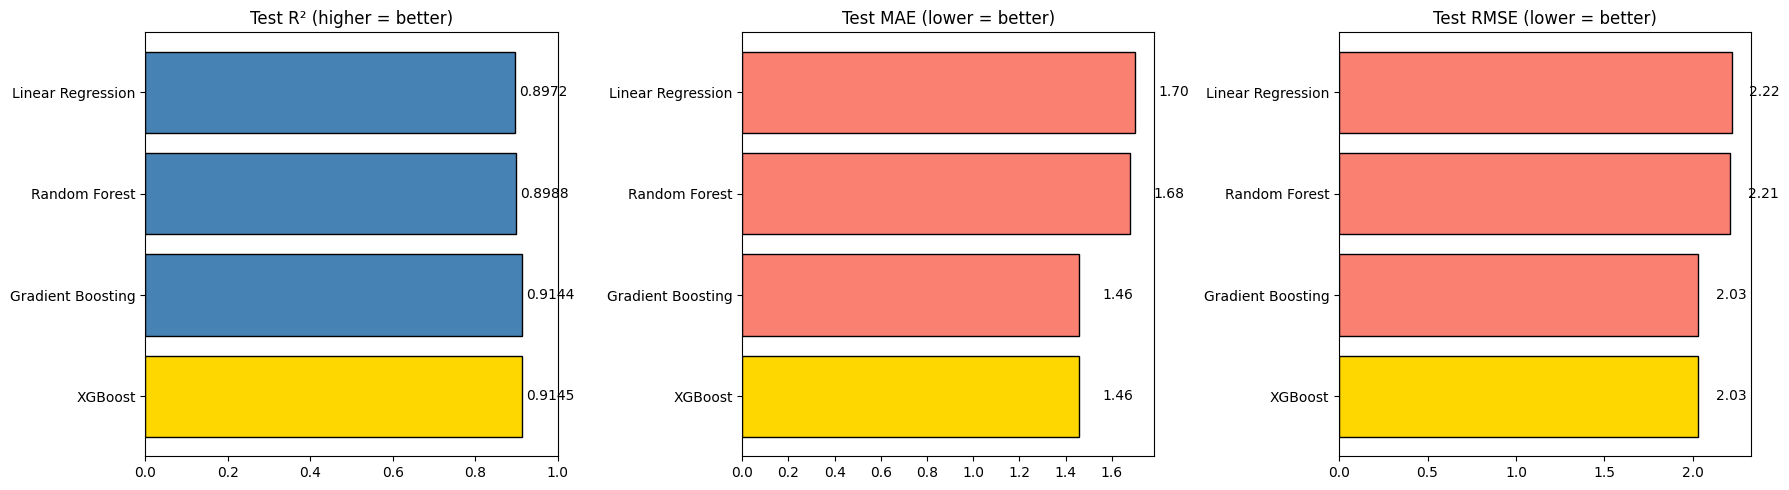

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_sorted = comp_df['Model'].values

# R²
colors_r2 = ['gold' if m == winner else 'steelblue' for m in models_sorted]
axes[0].barh(models_sorted, comp_df['Test R²'], color=colors_r2, edgecolor='black')
axes[0].set_title('Test R² (higher = better)')
axes[0].set_xlim(0, 1)
for i, v in enumerate(comp_df['Test R²']):
    axes[0].text(v + 0.01, i, f"{v:.4f}", va='center')

# MAE
colors_mae = ['gold' if m == winner else 'salmon' for m in models_sorted]
axes[1].barh(models_sorted, comp_df['Test MAE'], color=colors_mae, edgecolor='black')
axes[1].set_title('Test MAE (lower = better)')
for i, v in enumerate(comp_df['Test MAE']):
    axes[1].text(v + 0.1, i, f"{v:.2f}", va='center')

# RMSE
colors_rmse = ['gold' if m == winner else 'salmon' for m in models_sorted]
axes[2].barh(models_sorted, comp_df['Test RMSE'], color=colors_rmse, edgecolor='black')
axes[2].set_title('Test RMSE (lower = better)')
for i, v in enumerate(comp_df['Test RMSE']):
    axes[2].text(v + 0.1, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()

## 4. Feature Importance (Winner)


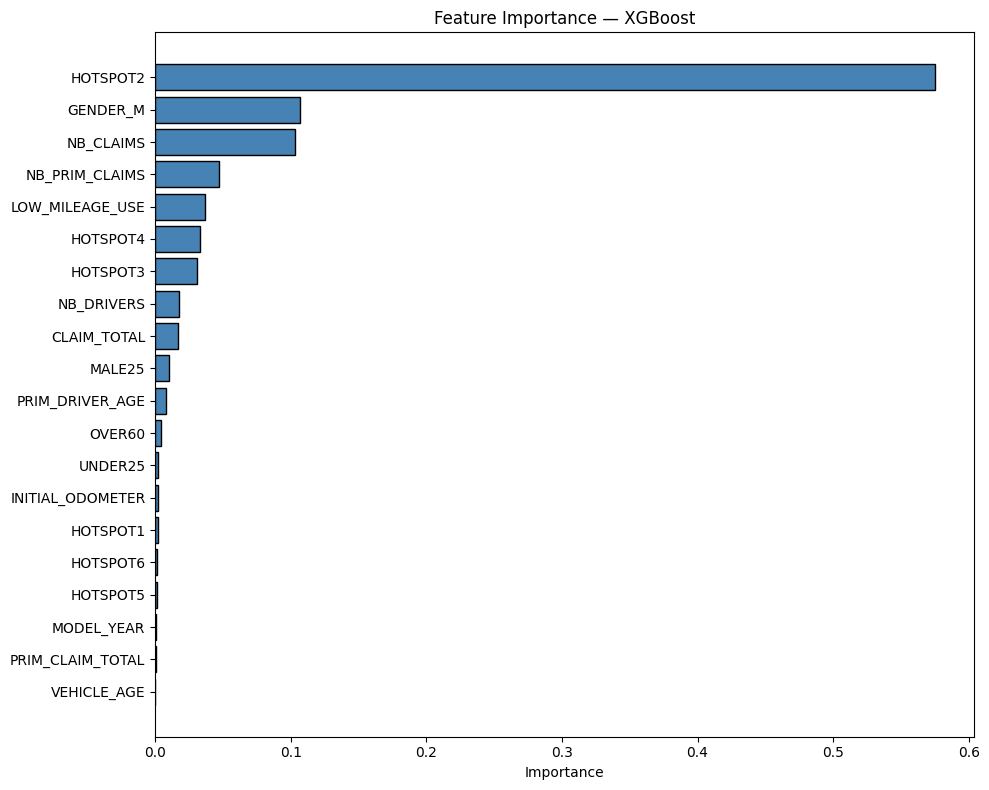


Top 5 features:
  HOTSPOT2                  0.5753
  GENDER_M                  0.1072
  NB_CLAIMS                 0.1029
  NB_PRIM_CLAIMS            0.0471
  LOW_MILEAGE_USE           0.0365


In [14]:
winner_pipe = results[winner]['pipeline']
model = winner_pipe.named_steps['model']

# Get feature names after preprocessing
feature_names = (
    all_numeric + 
    [f"GENDER_{cat}" for cat in ['M']] +
    binary_features
)

# Check if model has feature_importances_
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    
    feat_imp = pd.DataFrame({
        'feature': feature_names[:len(importances)],
        'importance': importances,
    }).sort_values('importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue', edgecolor='black')
    ax.set_title(f'Feature Importance — {winner}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print(f"\nTop 5 features:")
    for _, row in feat_imp.tail(5).iloc[::-1].iterrows():
        print(f"  {row['feature']:25s} {row['importance']:.4f}")
else:
    print(f"{winner} does not support feature_importances_")

## 5. Actual vs Predicted


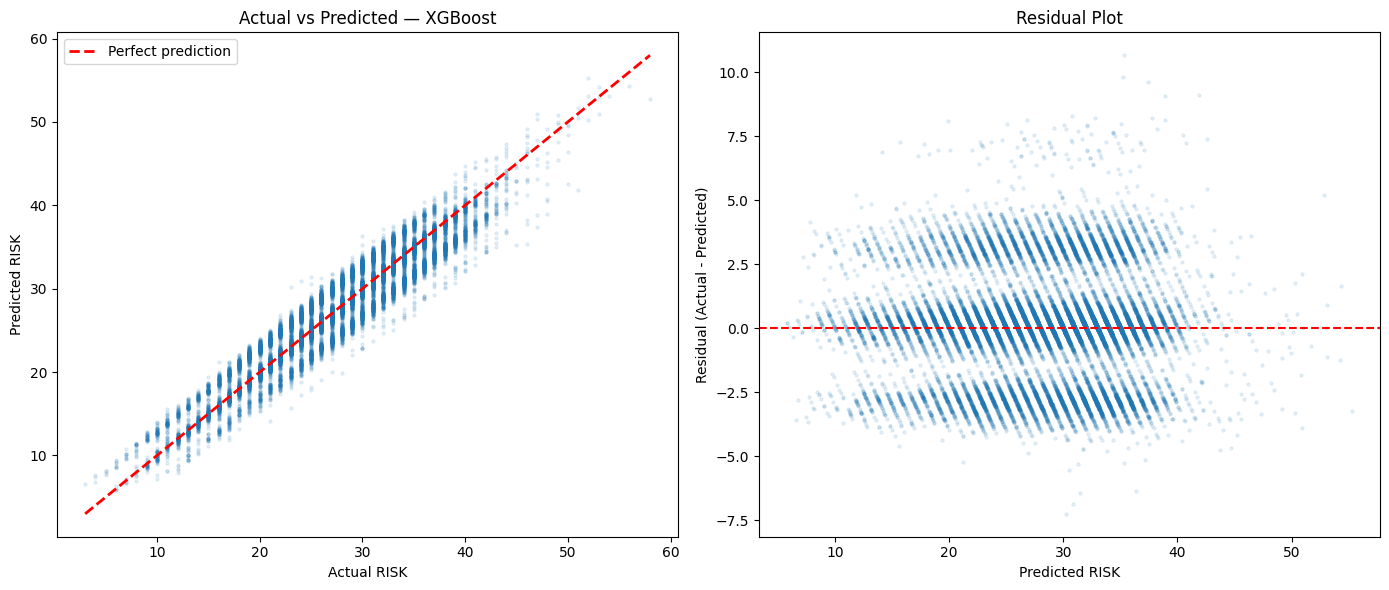

Residual stats:
  Mean: 0.007 (should be ~0)
  Std:  2.027


In [15]:
y_pred = winner_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter
axes[0].scatter(y_test, y_pred, alpha=0.1, s=5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title(f'Actual vs Predicted — {winner}')
axes[0].set_xlabel('Actual RISK')
axes[0].set_ylabel('Predicted RISK')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.1, s=5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted RISK')
axes[1].set_ylabel('Residual (Actual - Predicted)')

plt.tight_layout()
plt.show()

print(f"Residual stats:")
print(f"  Mean: {residuals.mean():.3f} (should be ~0)")
print(f"  Std:  {residuals.std():.3f}")

In [16]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("insurance-risk-score")

with mlflow.start_run(run_name="notebook-gradient-boosting"):
    # Log parameters
    mlflow.log_params({
        "model": winner,
        "n_estimators": winner_pipe.named_steps["model"].n_estimators,
        "max_depth": winner_pipe.named_steps["model"].max_depth,
        "learning_rate": winner_pipe.named_steps["model"].learning_rate,
        "source": "notebook",
    })

    # Log metrics
    y_pred = winner_pipe.predict(X_test)
    mlflow.log_metrics({
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": root_mean_squared_error(y_test, y_pred),
        "r2": r2_score(y_test, y_pred),
    })

    # Log model with registry name
    mlflow.sklearn.log_model(
        winner_pipe,
        "model",
        registered_model_name="insurance-risk-model",
    )

print("Model logged to MLflow")

2026/02/14 20:29:58 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/14 20:29:58 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/14 20:29:58 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/14 20:29:58 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/14 20:29:58 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/14 20:29:58 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/14 20:29:59 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/14 20:29:59 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/02/14 20:29:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/Users/omerpoyraz/Desktop/AI Eng/MLOps/insurance_mlops/.venv/lib/python3.12/site-packages/mlflow/models/model.py:1209: FutureWarning: Saving scikit-learn models in the pickle

Model logged to MLflow


Registered model 'insurance-risk-model' already exists. Creating a new version of this model...
Created version '3' of model 'insurance-risk-model'.


In [17]:

os.makedirs('data/model', exist_ok=True)
joblib.dump(winner_pipe, 'data/model/model_0.joblib')
print(f"Saved {winner} pipeline to data/model/model_0.joblib")

# Also save the merged dataset for reference
merged_df.to_csv('data/processed/training_data.csv', index=False)
print(f"Saved training data to data/processed/training_data.csv")

Saved XGBoost pipeline to data/model/model_0.joblib
Saved training data to data/processed/training_data.csv


---
### Conclusion

| Decision | Choice | Justification |
|----------|--------|---------------|
| **Clustering** | KMeans, K=6 | Highest silhouette, elbow at K=6 |
| **Model** | XGBoosting | Best Test R² and lowest MAE |

**Pipeline:** Db2 → Socrata → KMeans(K=6) → Hotspot Distances → [  XGBoosting] → Risk Score

